# 0. 데이터 불러오기

In [ ]:
# matplotlib 한글 깨짐방지
# 아래코드 실행후 '런타임 다시시작' 후 모듈 불러오기
# 참고 블로그: https://teddylee777.github.io/colab/colab-korean
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 0 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,778 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and 

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap

# 설치한 한글 폰트를 matplotlib에 등록
font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# =====================================================
# 🎨 공통 그래프 스타일 - 모든 시각화가 이 설정을 따름
# =====================================================
MAIN   = '#1B7A4A'   # 기본 색: 단일 시리즈는 전부 이 색
ACCENT = '#C77A12'   # 비교/강조 색 (성수기 등)
SUB    = '#4A6FB5'   # 세 번째 범주
LIME   = '#8FB339'   # 네 번째 범주
LINE   = '#C0392B'   # 회귀선 등 보조선
LIGHT  = '#CFE6D7'   # 박스플롯·바이올린 채움색
OTHER  = '#C9CDD1'   # '기타' 묶음 (회색)
INK, MUTED, GRID = '#333333', '#8C8C8C', '#E6E6E6'
SEQ3 = ['#A8D5B8', '#3E9A68', '#0E4D2E']      # 순서 있는 3구간 (연 → 진)
SEQ_CMAP = 'Greens'                           # 크기를 나타내는 히트맵
DIV_CMAP = LinearSegmentedColormap.from_list('div', [ACCENT, '#F2F2F2', MAIN])  # 상관계수(-1~1)

sns.set_theme(style='white', font='NanumGothic')
plt.rcParams.update({
    'figure.figsize': (10, 5.5), 'figure.dpi': 120,
    'axes.unicode_minus': False,
    'axes.edgecolor': '#BFBFBF', 'axes.labelcolor': INK,
    'axes.titlesize': 15, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.titlepad': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelsize': 10.5, 'ytick.labelsize': 10.5,
    'legend.frameon': False, 'legend.fontsize': 10.5,
})

# 박스플롯 공통 옵션: sns.boxplot(..., **BOX)
BOX = dict(color=LIGHT, linewidth=1.2, fliersize=3,
           boxprops={'edgecolor': MAIN}, whiskerprops={'color': MAIN},
           capprops={'color': MAIN}, medianprops={'color': MAIN, 'linewidth': 2},
           flierprops={'markerfacecolor': MAIN, 'markeredgecolor': 'white', 'alpha': 0.6})
# 산점도 공통 옵션: sns.scatterplot(..., **DOT)
DOT = dict(s=26, alpha=0.55, edgecolor='white', linewidth=0.4)

def man(x, pos=None):
    """관객 수를 '만' 단위로 표시 (1e6 표기 대신)"""
    if x >= 10000:
        return f'{x/10000:,.0f}만'
    return f'{x:,.0f}'

def style_ax(ax, title, xlabel='', ylabel='', ygrid=True, man_y=False, man_x=False):
    """모든 그래프 마무리: 제목·축이름·격자·단위"""
    ax.set_title(title, color=INK)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if ygrid:
        ax.grid(axis='y', color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for on, axis in [(man_y, ax.yaxis), (man_x, ax.xaxis)]:
        if on:
            axis.set_major_formatter(mticker.FuncFormatter(man))
            axis.set_minor_formatter(mticker.NullFormatter())
    plt.tight_layout()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/ESAA_YB_1조/movies_train.csv")

# 발표 1 - 1. 데이터 EDA

In [ ]:
df.head(3)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


In [ ]:
df.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,2.700000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,1.050443e+06,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.791408e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,2.038000e+04,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,4.784236e+05,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,1.286569e+06,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


In [ ]:
df['distributor'].value_counts()

,count
distributor,
CJ 엔터테인먼트,54
롯데엔터테인먼트,52
(주)NEW,30
(주)마운틴픽쳐스,29
(주)쇼박스,26
...,...
영화사 廊,1
크리에이티브컴즈(주),1
ysfilm,1


In [ ]:
df['genre'].value_counts()

,count
genre,
드라마,221
다큐멘터리,93
멜로/로맨스,78
코미디,53
공포,42
액션,28
느와르,27
애니메이션,21
미스터리,17


In [ ]:
df['director'].value_counts()

,count
director,
홍상수,7
우민호,4
전규환,4
신재호,4
장률,4
...,...
정윤석,1
이성은,1
권오광,1


In [ ]:
df['screening_rat'].value_counts()

,count
screening_rat,
청소년 관람불가,204
15세 관람가,202
12세 관람가,102
전체 관람가,92


# 2. 데이터 전처리

## 결측치 확인

In [ ]:
df.isna().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [ ]:
df[df['dir_prev_bfnum'].isna()].head(3)

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
6,길위에서,백두대간,다큐멘터리,2013-05-23,104,전체 관람가,이창재,NaN,0,32,5,53526
8,"1789, 바스티유의 연인들",유니버설픽쳐스인터내셔널코리아,뮤지컬,2014-09-18,129,전체 관람가,정성복,NaN,0,3,5,4778


In [ ]:
# 이전 영화 관객수가 결측인 행만 선택
missing_df = df[df['dir_prev_bfnum'].isna()]

# 해당 영화들의 감독 이전 영화 개수 확인
missing_df['dir_prev_num'].value_counts()

,count
dir_prev_num,
0,330


dir_prev_bfnum이 결측인 330개 행은 모두 dir_prev_num이 0이었다. 기록된 이전 영화가 없어 발생한 결측으로 판단하여 0으로 대체하였다.

In [ ]:
df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)

In [ ]:
df.isna().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,0
dir_prev_num,0
num_staff,0


# 3. 데이터 시각화

## Y분포 확인 - 관객수

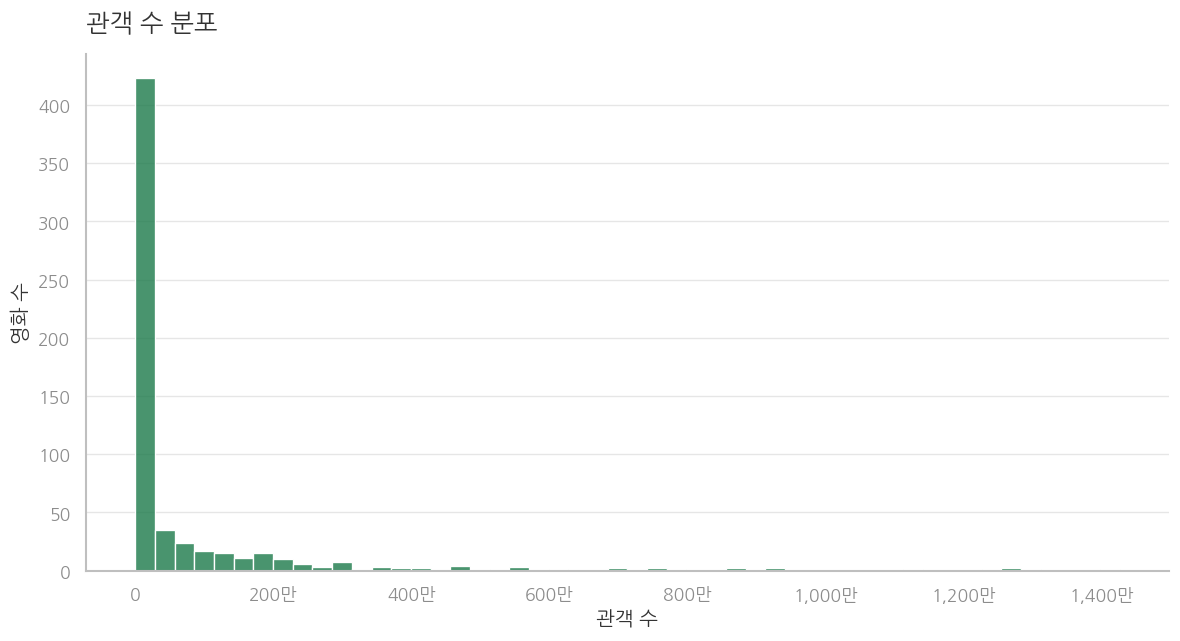

In [ ]:
fig, ax = plt.subplots()
sns.histplot(x='box_off_num', data=df, bins=50, color=MAIN, alpha=0.8,
             edgecolor='white', linewidth=0.8, ax=ax)
style_ax(ax, '관객 수 분포', xlabel='관객 수', ylabel='영화 수')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(man))
plt.show()

y의 분포를 확인한 결과 관객수가 적은 구간에 영화가 집중되어 있고, 일부 영화는 매우 높은 관객수를 기록하여 오른쪽 꼬리가 긴 분포를 보인다. 이후 변수별 비교에서 낮은 관객수 구간이 잘 구분되지 않는다면 로그 변환을 고려한다.

In [ ]:
df['box_off_num'].describe()

,box_off_num
count,6.000000e+02
mean,7.081818e+05
std,1.828006e+06
min,1.000000e+00
25%,1.297250e+03
50%,1.259100e+04
75%,4.798868e+05
max,1.426277e+07


##  발표 2 - 상관계수 확인

In [ ]:
# 숫자형 변수 간 상관계수
corr_df = df.corr(numeric_only=True)
corr_df

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
time,1.000000,0.266065,0.306727,0.623205,0.114153,0.441452
dir_prev_bfnum,0.266065,1.000000,0.396616,0.369657,0.042491,0.293791
dir_prev_num,0.306727,0.396616,1.000000,0.450706,0.014006,0.259674
num_staff,0.623205,0.369657,0.450706,1.000000,0.077871,0.544265
num_actor,0.114153,0.042491,0.014006,0.077871,1.000000,0.111179
box_off_num,0.441452,0.293791,0.259674,0.544265,0.111179,1.000000


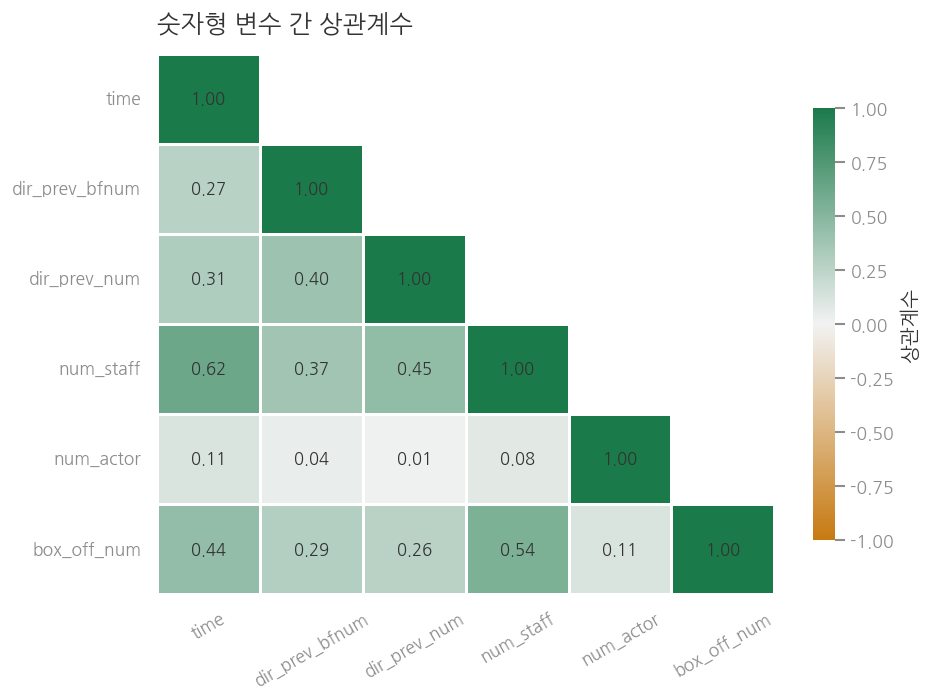

In [ ]:
corr_df = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)   # 위쪽 삼각형은 중복이라 가림

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap=DIV_CMAP, vmin=-1, vmax=1,
            linewidths=1.5, linecolor='white', annot_kws={'fontsize': 10, 'color': INK},
            cbar_kws={'label': '상관계수', 'shrink': 0.8}, ax=ax)
ax.tick_params(axis='x', rotation=30)
style_ax(ax, '숫자형 변수 간 상관계수', ygrid=False)
plt.show()

## 스태프 수와 관객수간의 관계

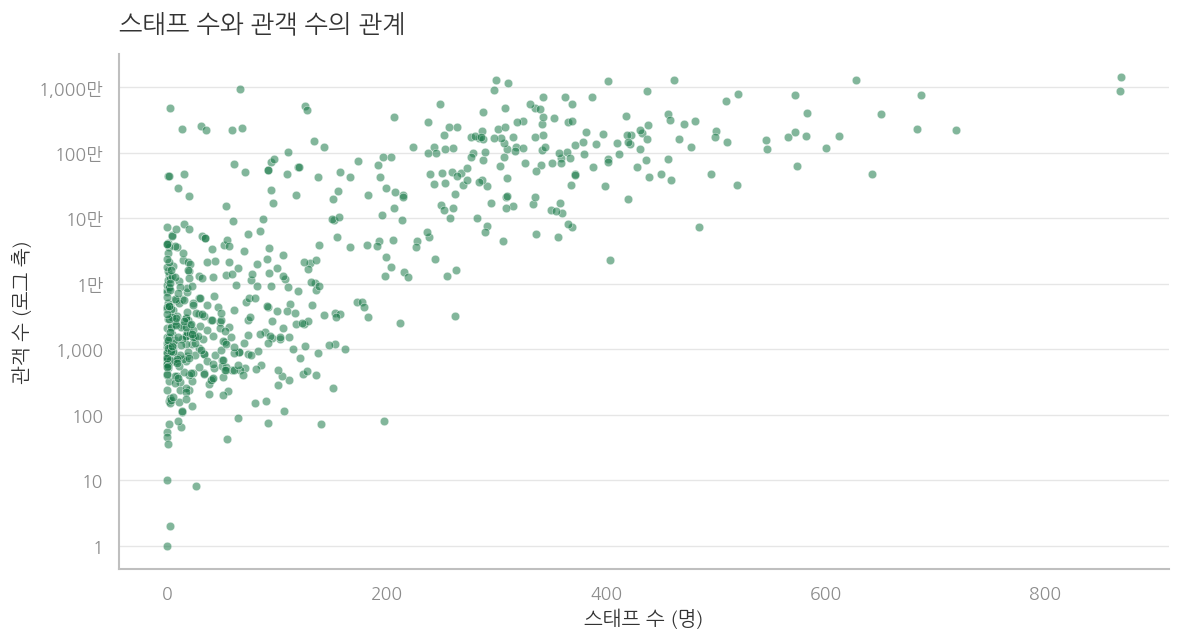

In [ ]:
fig, ax = plt.subplots()
sns.scatterplot(x='num_staff', y='box_off_num', data=df, color=MAIN, **DOT, ax=ax)
ax.set_yscale('log')
style_ax(ax, '스태프 수와 관객 수의 관계', xlabel='스태프 수 (명)', ylabel='관객 수 (로그 축)', man_y=True)
plt.show()

In [ ]:
df['dir_prev_num'].value_counts().sort_index()

,count
dir_prev_num,
0,330
1,113
2,86
3,47
4,20
5,4


## 배우 수와 관객수

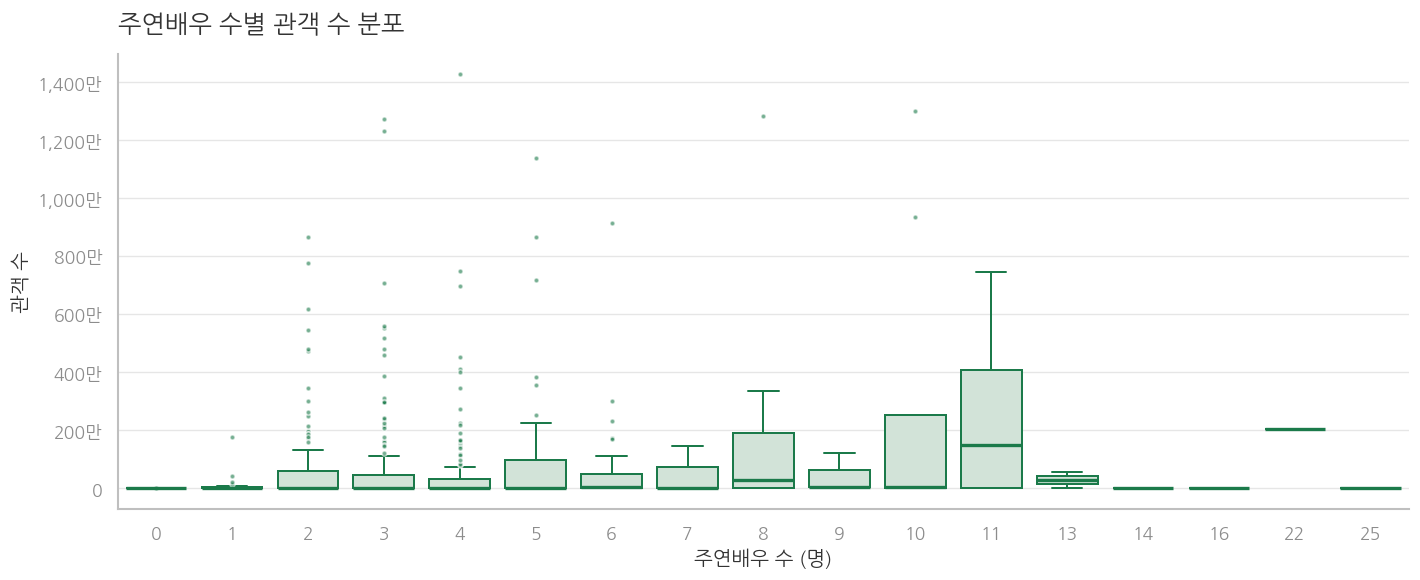

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x='num_actor', y='box_off_num', data=df, **BOX, ax=ax)
style_ax(ax, '주연배우 수별 관객 수 분포', xlabel='주연배우 수 (명)', ylabel='관객 수', man_y=True)
plt.show()

## 관람등급별 관객수 분포

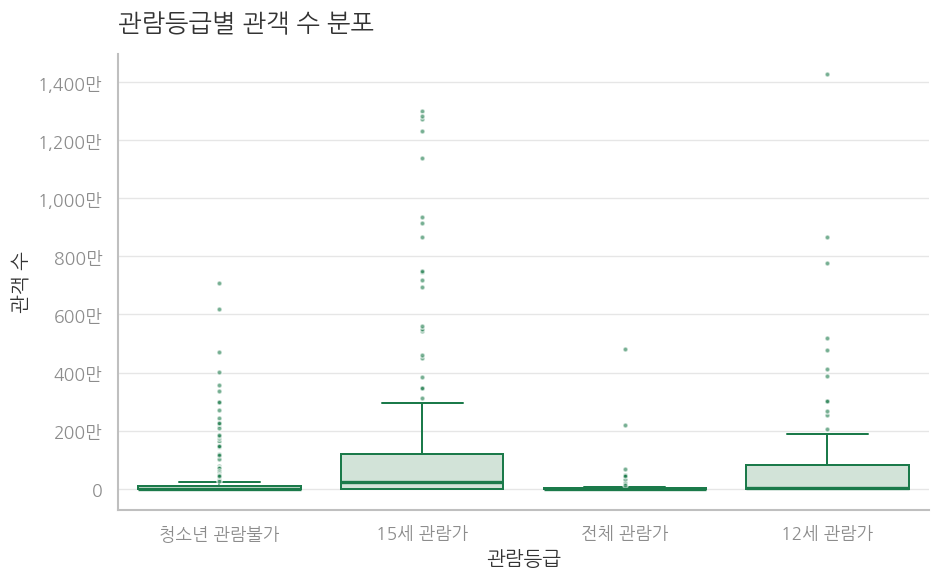

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='screening_rat', y='box_off_num', data=df, **BOX, ax=ax)
style_ax(ax, '관람등급별 관객 수 분포', xlabel='관람등급', ylabel='관객 수', man_y=True)
plt.show()

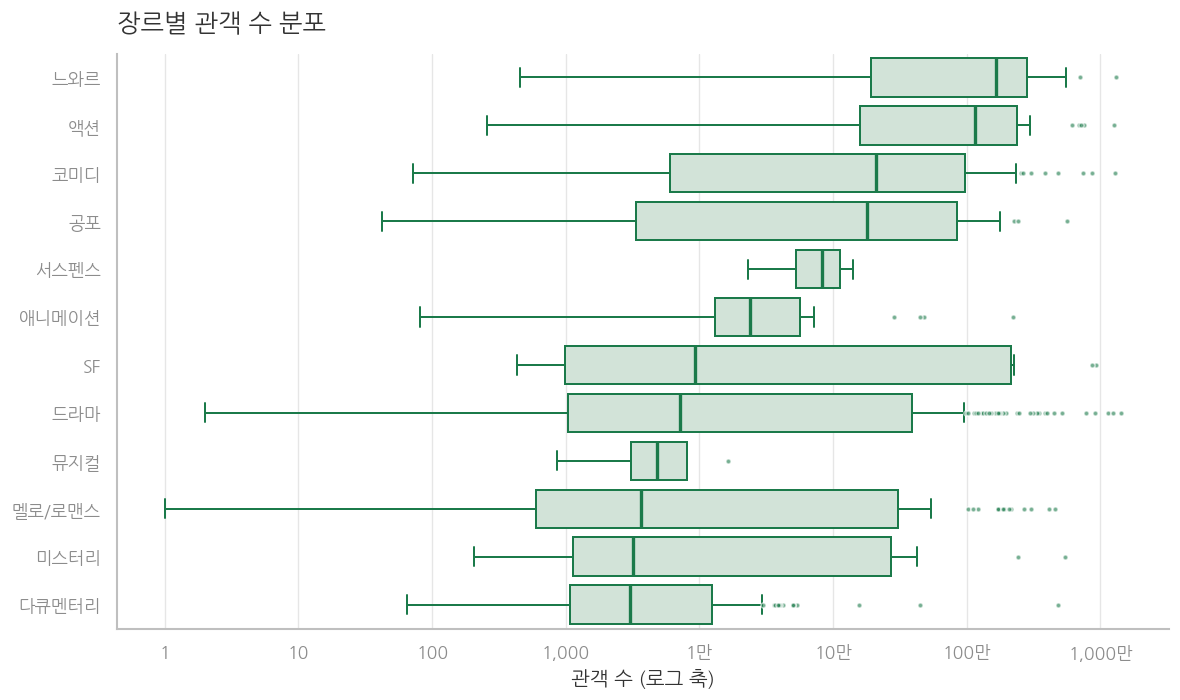

In [ ]:
genre_order = df.groupby('genre')['box_off_num'].median()
genre_order = genre_order.sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='box_off_num', y='genre', data=df, order=genre_order, **BOX, ax=ax)
ax.set_xscale('log')
style_ax(ax, '장르별 관객 수 분포', xlabel='관객 수 (로그 축)', ylabel='', ygrid=False, man_x=True)
ax.grid(axis='x', color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.show()

감독의 이전 영화 관객수는 0으로 채운 영화들을 제외한 비교도 추가

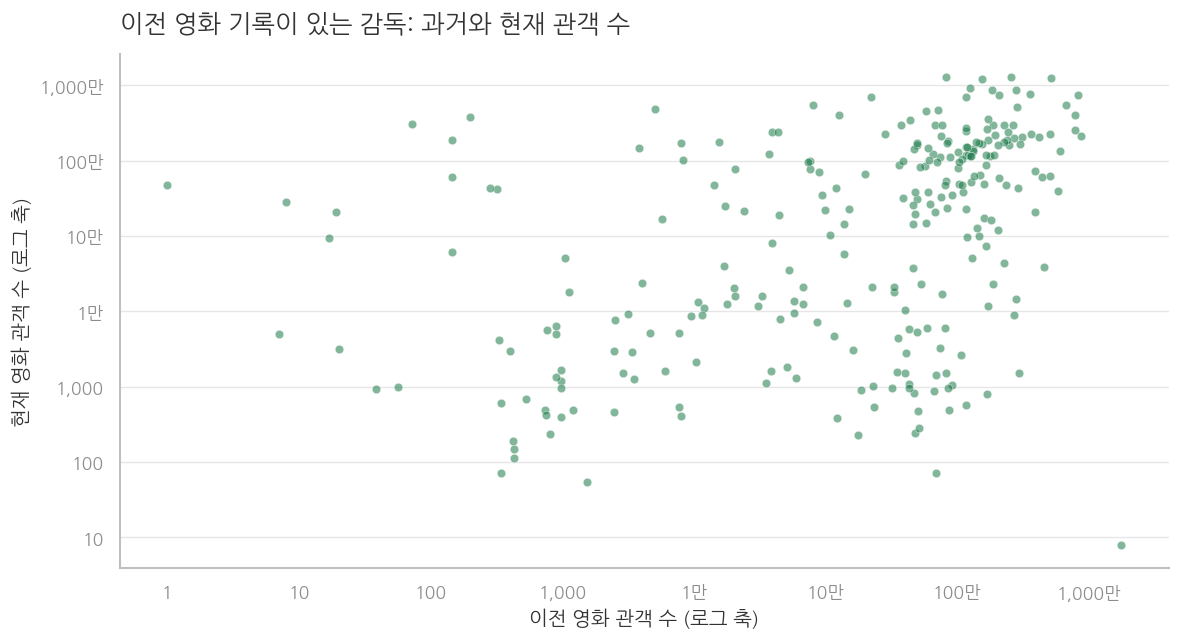

In [ ]:
# 기록된 이전 영화가 있는 경우만 선택
experienced_df = df[df['dir_prev_num'] > 0]

fig, ax = plt.subplots()
sns.scatterplot(x='dir_prev_bfnum', y='box_off_num', data=experienced_df, color=MAIN, **DOT, ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
style_ax(ax, '이전 영화 기록이 있는 감독: 과거와 현재 관객 수',
         xlabel='이전 영화 관객 수 (로그 축)', ylabel='현재 영화 관객 수 (로그 축)', man_x=True, man_y=True)
plt.show()

스태프 수와 관객

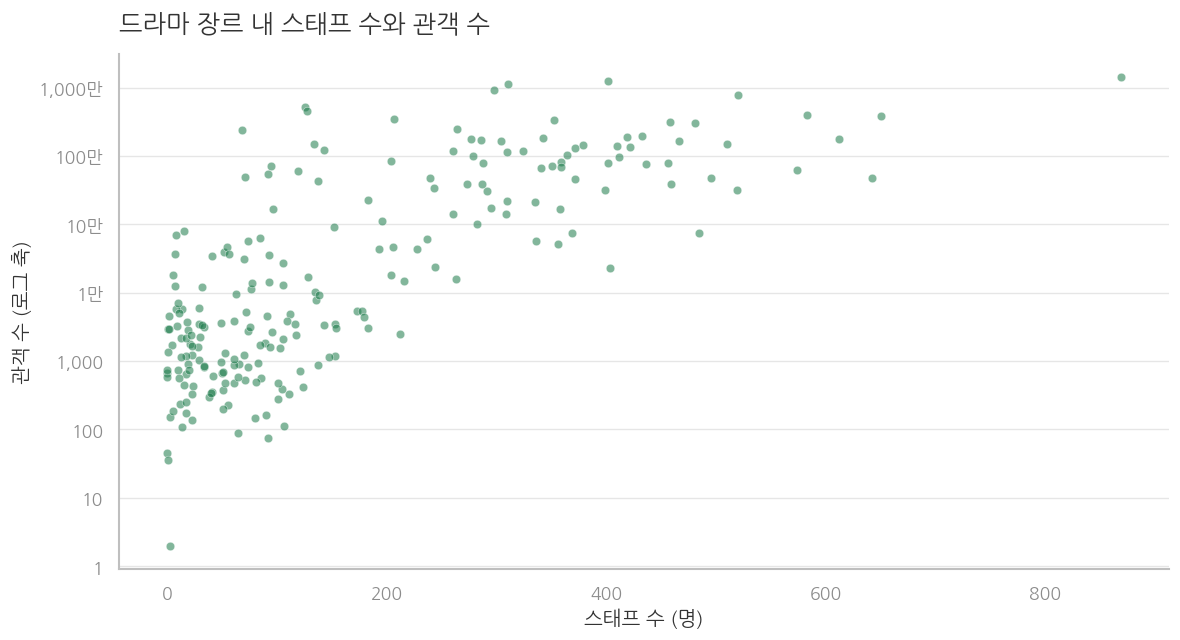

In [ ]:
drama_df = df[df['genre'] == '드라마']

fig, ax = plt.subplots()
sns.scatterplot(x='num_staff', y='box_off_num', data=drama_df, color=MAIN, **DOT, ax=ax)
ax.set_yscale('log')
style_ax(ax, '드라마 장르 내 스태프 수와 관객 수', xlabel='스태프 수 (명)', ylabel='관객 수 (로그 축)', man_y=True)
plt.show()

In [ ]:
drama_df[['num_staff', 'box_off_num']].corr()

,num_staff,box_off_num
num_staff,1.000000,0.502383
box_off_num,0.502383,1.000000


In [ ]:
def staff_group(staff):
    if staff < 100:
        return '100명 미만'
    elif staff < 200:
        return '100~199명'
    else:
        return '200명 이상'

df['staff_group'] = df['num_staff'].apply(staff_group)

# 새로 만든 변수가 포함되도록 드라마 데이터 다시 선택
drama_df = df[df['genre'] == '드라마']

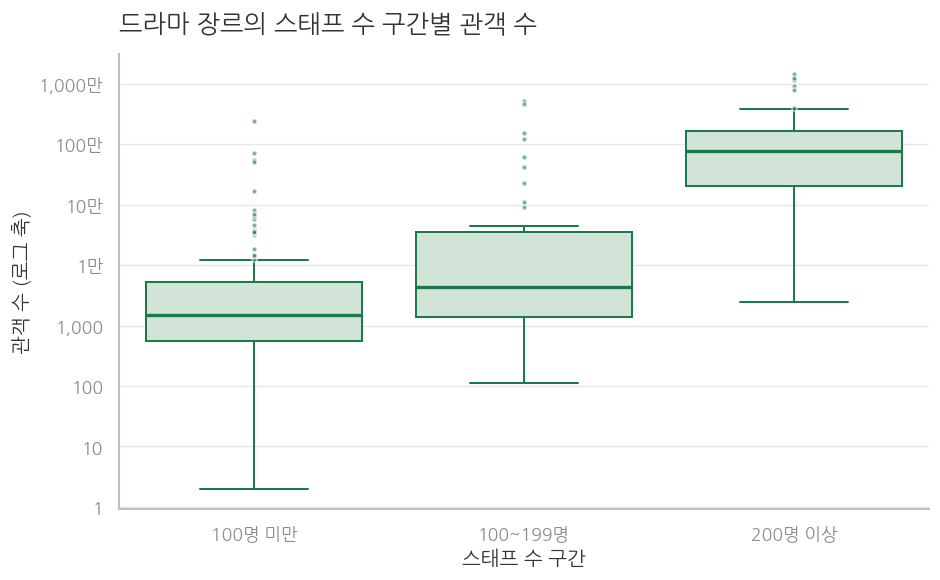

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='staff_group', y='box_off_num', order=['100명 미만', '100~199명', '200명 이상'],
            data=drama_df, **BOX, ax=ax)
ax.set_yscale('log')
style_ax(ax, '드라마 장르의 스태프 수 구간별 관객 수', xlabel='스태프 수 구간', ylabel='관객 수 (로그 축)', man_y=True)
plt.show()

In [ ]:
drama_df.groupby('staff_group')['box_off_num'].agg(['count', 'median'])

,count,median
staff_group,,
100~199명,39,4398.0
100명 미만,110,1489.0
200명 이상,72,776607.5


## 발표 3 - 장르

### 장르별 관객수 분포

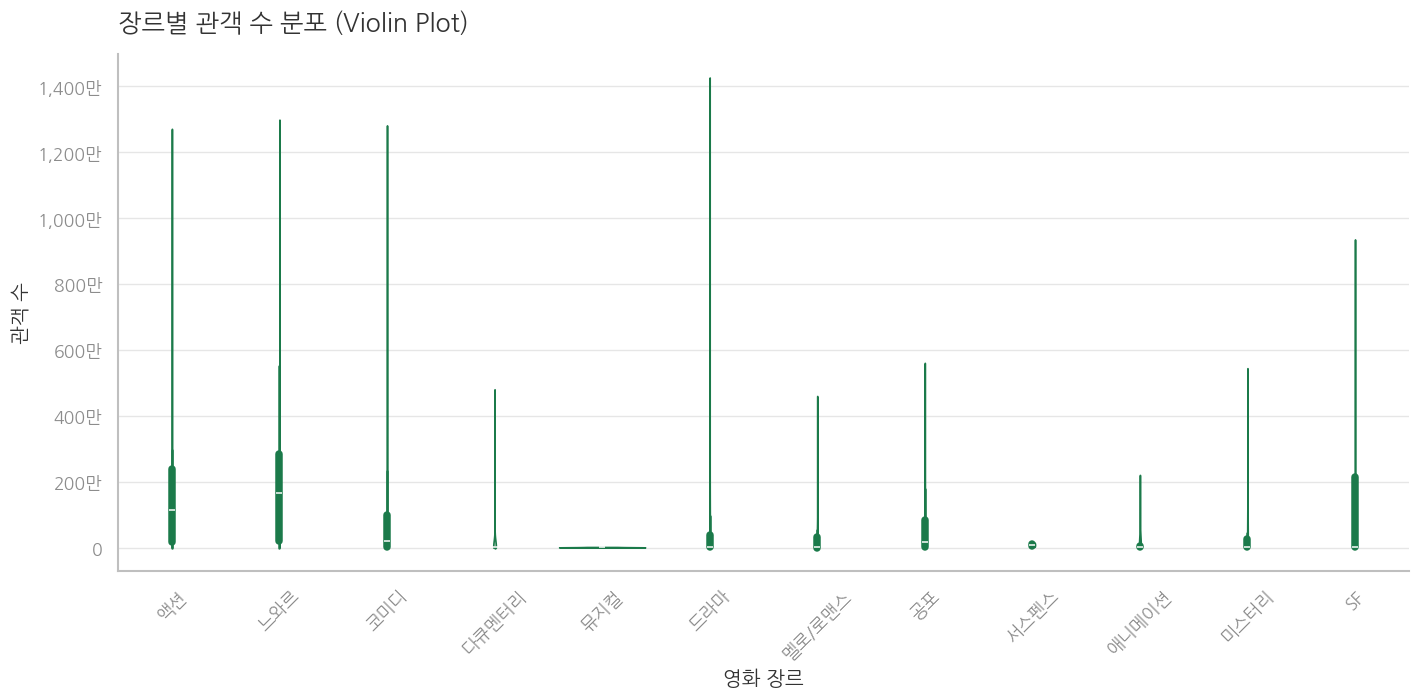

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# inner='box': 바이올린 안에 박스플롯을 함께 그려 중앙값·사분위수 확인
sns.violinplot(data=df, x='genre', y='box_off_num', color=LIGHT, inner='box',
               linecolor=MAIN, linewidth=1, cut=0, ax=ax)   # cut=0: 음수 구간이 그려지지 않게
ax.tick_params(axis='x', rotation=45)
style_ax(ax, '장르별 관객 수 분포 (Violin Plot)', xlabel='영화 장르', ylabel='관객 수', man_y=True)
plt.show()

### 개봉일+장르와 관객수
연도별로 어떤 장르가 인기가 많았는지

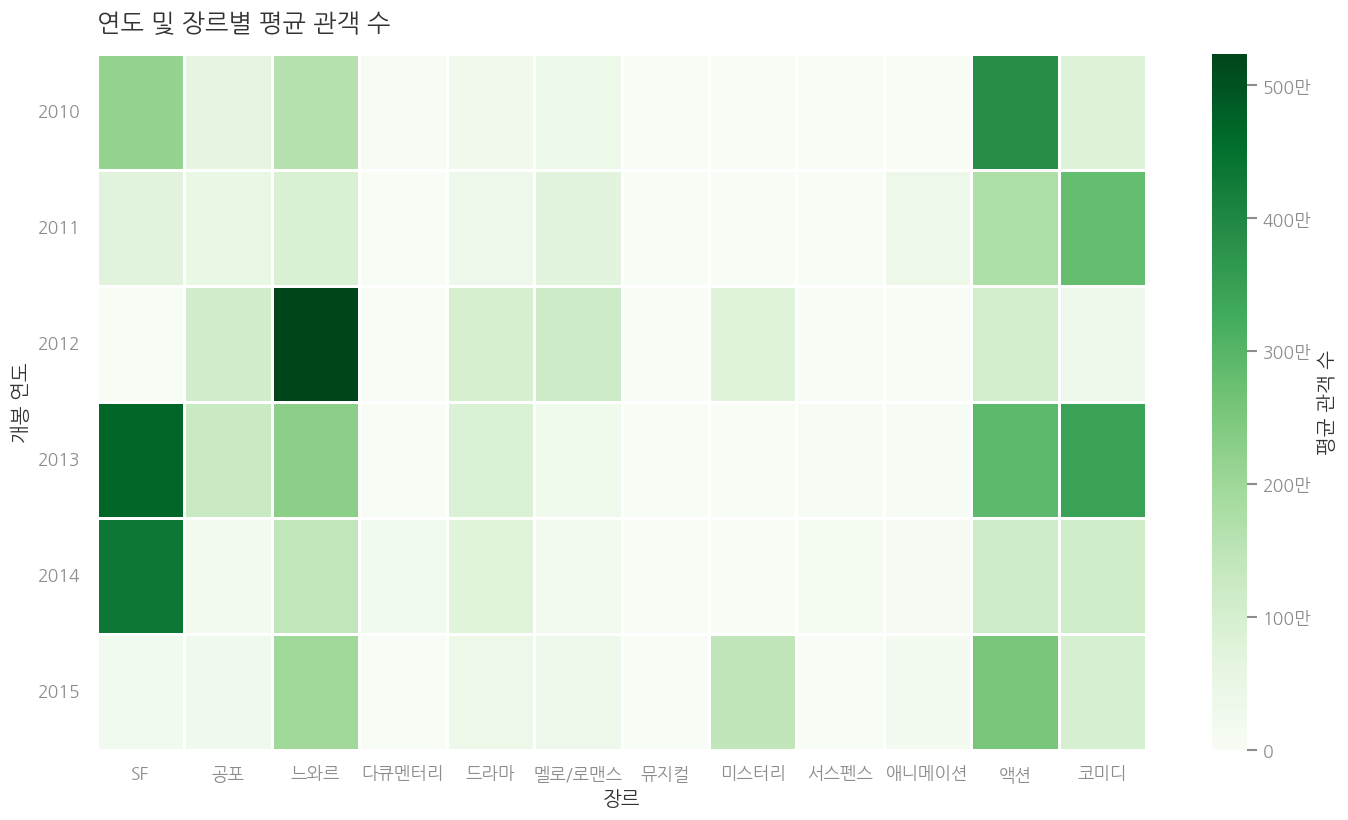

In [ ]:
df['release_time'] = pd.to_datetime(df['release_time'])
df['release_year'] = df['release_time'].dt.year

genre_trend = df.pivot_table(index='release_year', columns='genre', values='box_off_num', aggfunc='mean')
genre_trend = genre_trend.fillna(0)  # 해당 연도에 개봉한 장르가 없는 경우

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(genre_trend, cmap=SEQ_CMAP, linewidths=1.5, linecolor='white',
            cbar_kws={'label': '평균 관객 수', 'format': mticker.FuncFormatter(man)}, ax=ax)
ax.tick_params(axis='y', rotation=0)
style_ax(ax, '연도 및 장르별 평균 관객 수', xlabel='장르', ylabel='개봉 연도', ygrid=False)
plt.show()

### 연도별 유행 장르

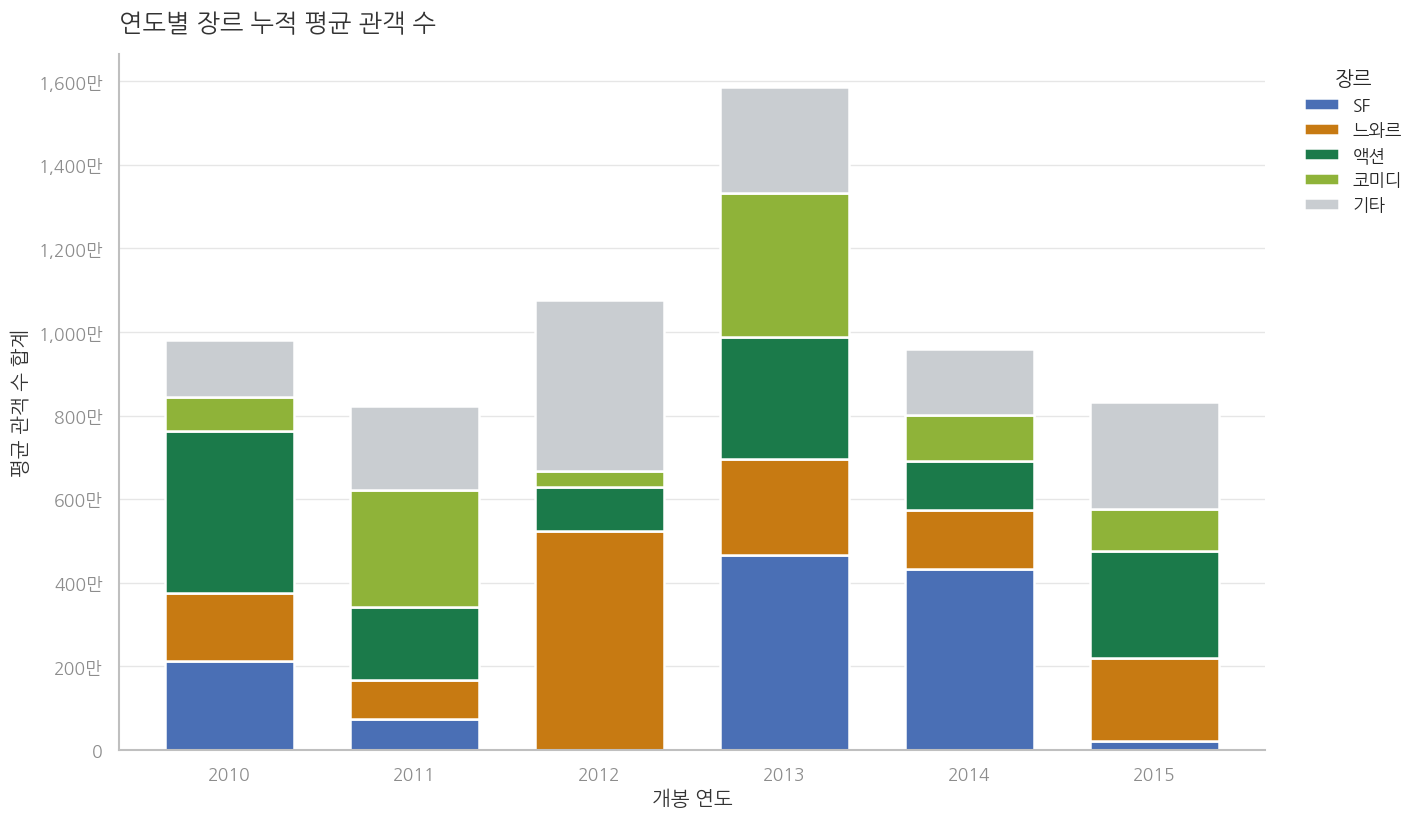

In [ ]:
# 장르가 12개라 색이 다 구분되지 않음 → 해석에 등장하는 4개 장르만 색, 나머지는 '기타'(회색)
focus = {'SF': SUB, '느와르': ACCENT, '액션': MAIN, '코미디': LIME}
stack_df = genre_trend[list(focus)].copy()
stack_df['기타'] = genre_trend.drop(columns=list(focus)).sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
stack_df.plot(kind='bar', stacked=True, color=list(focus.values()) + [OTHER],
              width=0.7, edgecolor='white', linewidth=1.5, ax=ax)
ax.legend(title='장르', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
style_ax(ax, '연도별 장르 누적 평균 관객 수', xlabel='개봉 연도', ylabel='평균 관객 수 합계', man_y=True)
plt.show()

- 영화 시장의 연도별 흥행 규모 변화 (전체 막대 높이)
: 막대의 전체 높이는 해당 연도에 개봉한 영화들의 평균적인 흥행 규모를 나타냄.
2013년의 막대가 가장 높게 솟아 있는 것을 볼 때, 2013년은 다양한 장르가 골고루 큰 평균 관객수를 기록하며 영화 시장이 가장 호황을 누렸던 해로 해석할 수 있음.
- 특정 장르의 급부상: 느와르(주황색)의 약진
: 2010년과 2011년에는 비중이 매우 작았던 느와르(주황색) 장르가 2012년에 폭발적으로 성장하여 그 해 평균 관객수의 절반 가까이를 차지.
이후 2013년, 2014년, 2015년에도 꾸준히 상당한 비중(주황색 블록)을 유지하고 있어, 2012년을 기점으로 느와르가 한국 영화계의 주요 흥행 장르로 완전히 자리 잡았음을 보여줌.
- 기복이 심한 장르: SF(파란색)
: SF(파란색) 장르는 2010년, 2013년, 2014년에는 하단에 거대한 블록을 형성하며 그 해의 흥행을 주도함.
하지만 2011년, 2012년, 2015년에는 막대가 거의 보이지 않을 정도로 비중이 축소됨. 이는 SF 장르가 꾸준히 개봉하기보다는, 특정 연도에 대자본이 투입된 대작 영화가 개봉했을 때만 평균 관객수를 크게 견인하는 특징이 있다고 해석할 수 있음.
- 꾸준한 스테디셀러: 액션(초록색)과 코미디(연두색)
: 액션(초록색)은 전체에 걸쳐 막대 상단에서 꾸준히 넓은 비중을 차지하고 있음.
코미디(연두색) 역시 2011년과 2013년에 큰 비중을 보여주며, 한국 영화 시장에서 관객들이 호불호 없이 꾸준히 찾는 스테디셀러 역할을 하고 있음을 알 수 있음.

#### 결론
한국 영화 시장은 액션/코미디라는 안정적인 스테디셀러 기반 위에, 특정 연도에 느와르나 SF 같은 킬러 장르가 유행을 주도하며 전체 시장의 파이를 키우는 구조를 띠고 있다.

## 감독

### 감독의 이전 영화 개수와 관객수

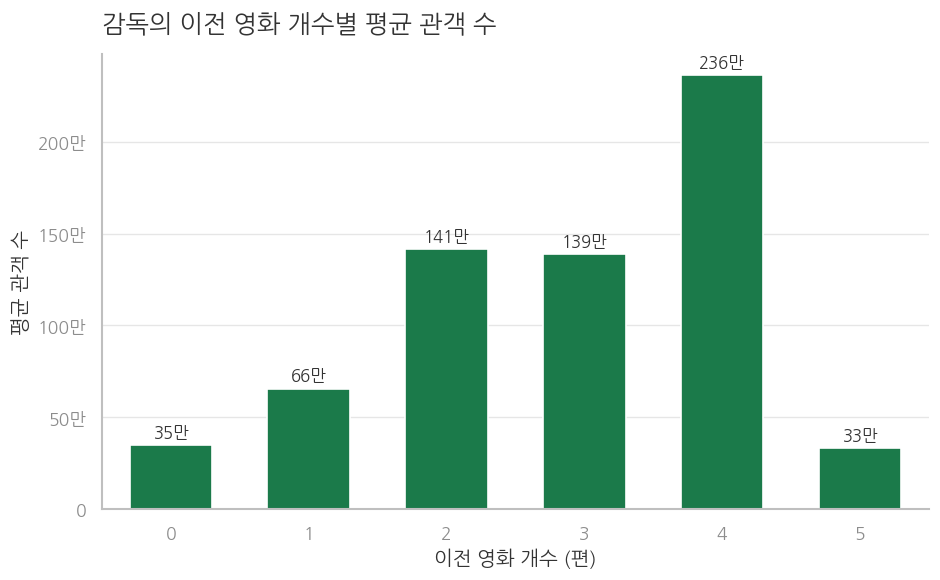

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='dir_prev_num', y='box_off_num', data=df, color=MAIN, saturation=1,
            errorbar=None, width=0.6, ax=ax)
for c in ax.containers:
    ax.bar_label(c, labels=[f'{v/10000:.0f}만' for v in c.datavalues], fontsize=10, color=INK, padding=3)
style_ax(ax, '감독의 이전 영화 개수별 평균 관객 수', xlabel='이전 영화 개수 (편)', ylabel='평균 관객 수', man_y=True)
plt.show()

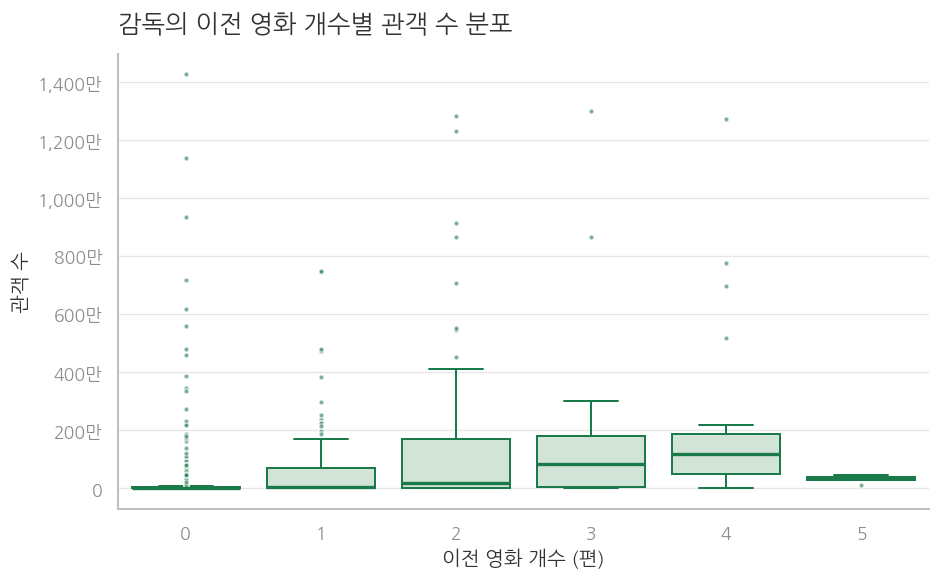

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='dir_prev_num', y='box_off_num', data=df, **BOX, ax=ax)
style_ax(ax, '감독의 이전 영화 개수별 관객 수 분포', xlabel='이전 영화 개수 (편)', ylabel='관객 수', man_y=True)
plt.show()

### 감독의 이전 영화 관객수와 현재 관객수
 감독의 과거 흥행 성적이 이번 영화의 흥행을 보장할까?

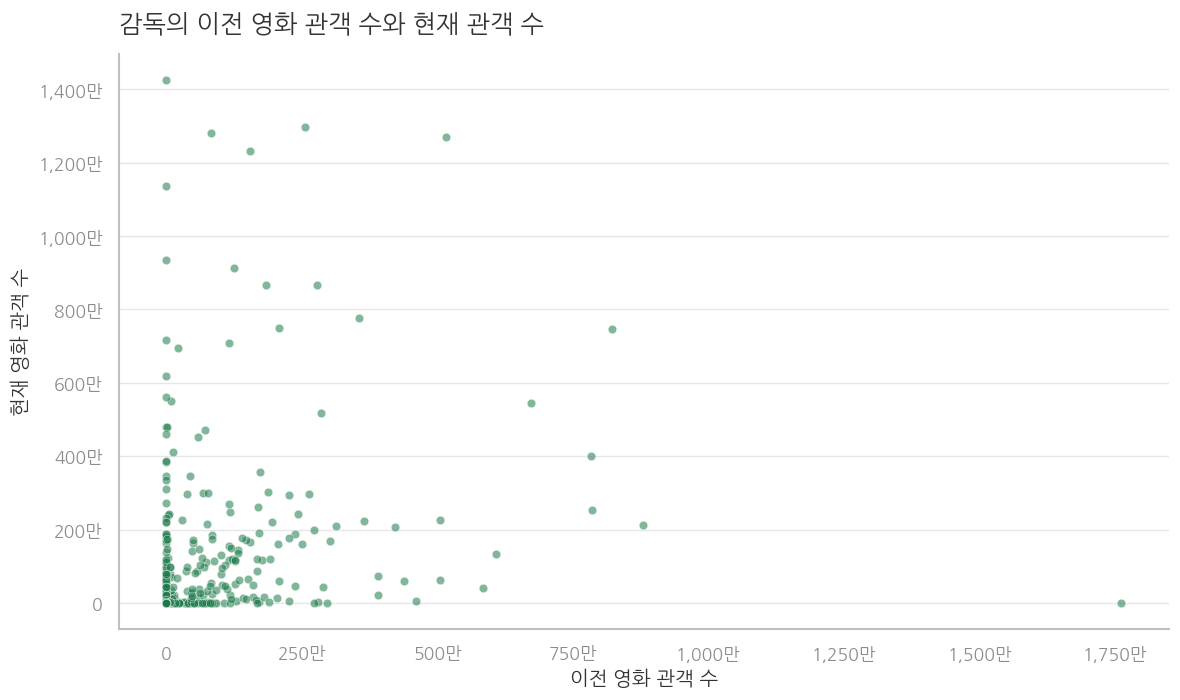

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='dir_prev_bfnum', y='box_off_num', color=MAIN, **DOT, ax=ax)
style_ax(ax, '감독의 이전 영화 관객 수와 현재 관객 수',
         xlabel='이전 영화 관객 수', ylabel='현재 영화 관객 수', man_x=True, man_y=True)
plt.show()

- 뚜렷한 상관관계가없음
- x=0축에 몰린 '신인 감독'들의 대박케이스
- 우측 하단의 극단적인 이상치

### 배급사와 감독의 이전 제작 영화수
대형배급사일수록 신인 감독을 선호하는지 베테랑 감독을 선호하는지

배급사 규모별 평균 이전 제작 영화 수
dist_size
대형    1.537037
중소    0.632420
Name: dir_prev_num, dtype: float64
------------------------------------------



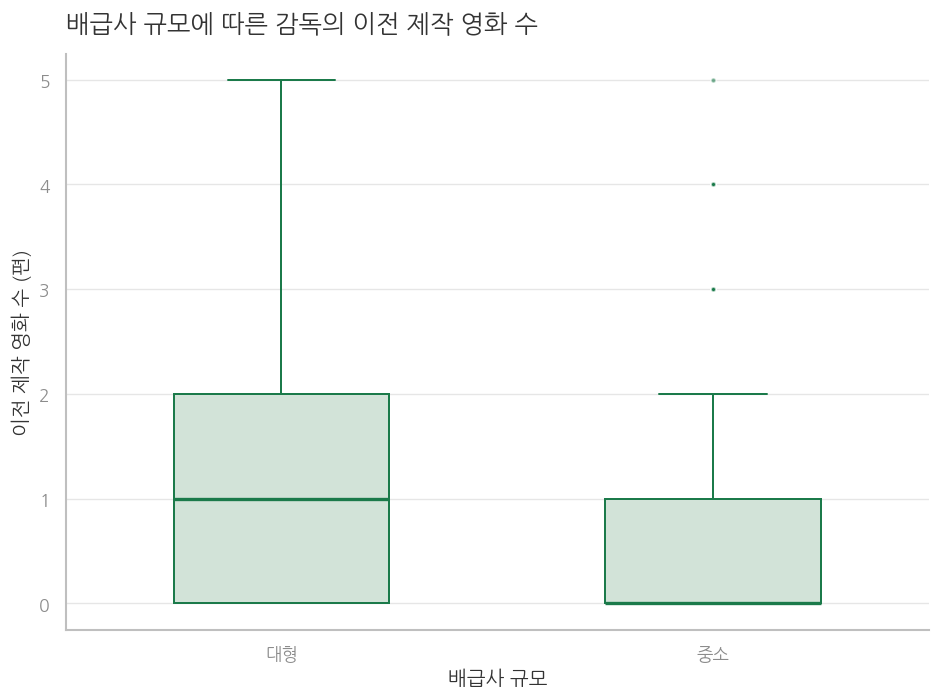

In [ ]:
# 데이터 전처리: 대형 배급사 vs 중소 배급사 그룹화
# 상위 4개 대형 배급사 리스트
major_distributors = ['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)쇼박스', '(주)NEW']

# 배급사가 major_distributors 리스트에 있으면 '대형', 아니면 '중소'로 분류
df['dist_size'] = df['distributor'].apply(lambda x: '대형' if x in major_distributors else '중소')

# 그룹별 평균 이전 제작 영화 수 출력
print("배급사 규모별 평균 이전 제작 영화 수")
print(df.groupby('dist_size')['dir_prev_num'].mean())
print("------------------------------------------\n")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='dist_size', y='dir_prev_num', order=['대형', '중소'], **BOX, width=0.5, ax=ax)
style_ax(ax, '배급사 규모에 따른 감독의 이전 제작 영화 수', xlabel='배급사 규모', ylabel='이전 제작 영화 수 (편)')
plt.show()

- Mean 비교
: 출력 결과를 보면 대형 배급사가 기용한 감독의 평균 이전 제작 영화 수는 약 1.54편인 반면, 중소 배급사는 약 0.63편이다. 수치상으로 대형 배급사가 중소 배급사보다 약 2.4배 이상 제작 경험이 많은 감독을 고용하고 있음을 보여준다.
- Box Plot의 Median의 차이
: 상자 내부의 가로선인 중앙값을 보면 대형 배급사의 중앙값은 1편이지만, 중소 배급사의 중앙값은 0편에 닿아 있다. 이는 중소 배급사가 투자한 영화의 절반 이상이 이전 작품이 전혀 없는 '신인 감독'의 데뷔작이라는 것을 의미한다.
- Boxplot의 분포 해석(데이터의 퍼짐 정도)
: 대형 배급사의 상자는 위로 넓게 형성되어 있으며 위쪽 꼬리가 5편까지 길게 뻗어 있다. 반면 중소 배급사의 상자는 0과 1 사이에 좁게 몰려 있다. 대형 배급사일수록 기성 감독들의 기용 풀이 훨씬 넓다는 것이 시각적으로 증명된다.
- 중소 배급사의 이상치
: 중소 배급사 상자 위쪽을 보면 3편, 4편, 5편 위치에 outlier가 존재한다. 이는 중소 배급사에서도 가끔 경험이 많은 베테랑 감독과 작업하는 경우가 있음을 나타내지만, 박스 바깥에 위치한 '이상치'이므로 보편적인 경향이라기보다는 예외적인 케이스로 해석하는 것이 타당하다.

####결론
자본 투입 규모가 큰 대형 배급사(CJ, 롯데, 쇼박스, NEW)일수록 흥행 실패 리스크를 최소화하기 위해 이미 제작 경험이 검증된 베테랑 감독을 선호하는 뚜렷한 경향을 보였다. 반면, 중소 배급사의 경우 기용한 감독의 중앙값이 '0편'으로 나타나, 신인 감독들에게 더 많은 기회와 데뷔 등용문을 제공하고 있음을 확인할 수 있었다.

## 발표 4 - 시기

### 성수기 vs 비성수기 장르별 평균 관객 수 비교

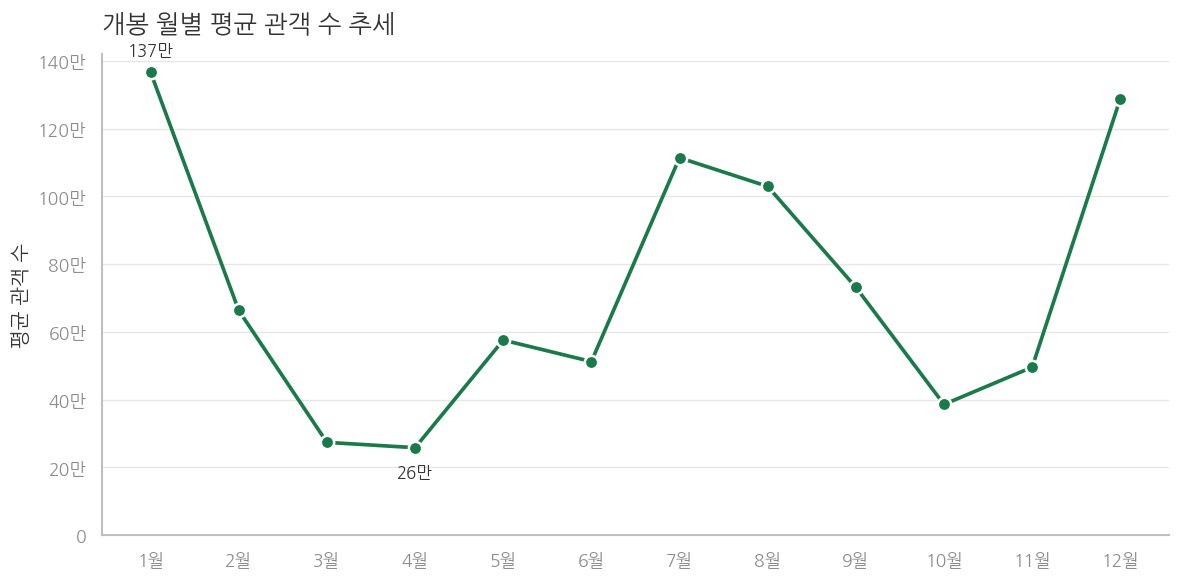

In [ ]:
# 1. 월(month) 정보 추출
df['month'] = df['release_time'].dt.month
month_mean = df.groupby('month')['box_off_num'].mean()

# 2. 선 그래프 시각화
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(month_mean.index, month_mean.values, color=MAIN, linewidth=2.2,
        marker='o', markersize=8, markeredgecolor='white', markeredgewidth=1.5)
for m, dy in [(month_mean.idxmax(), 10), (month_mean.idxmin(), -18)]:   # 최고·최저 달만 라벨
    ax.annotate(f'{month_mean[m]/10000:.0f}만', (m, month_mean[m]),
                textcoords='offset points', xytext=(0, dy), ha='center', fontsize=10, color=INK)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_ylim(0, None)
style_ax(ax, '개봉 월별 평균 관객 수 추세', ylabel='평균 관객 수', man_y=True)
plt.show()

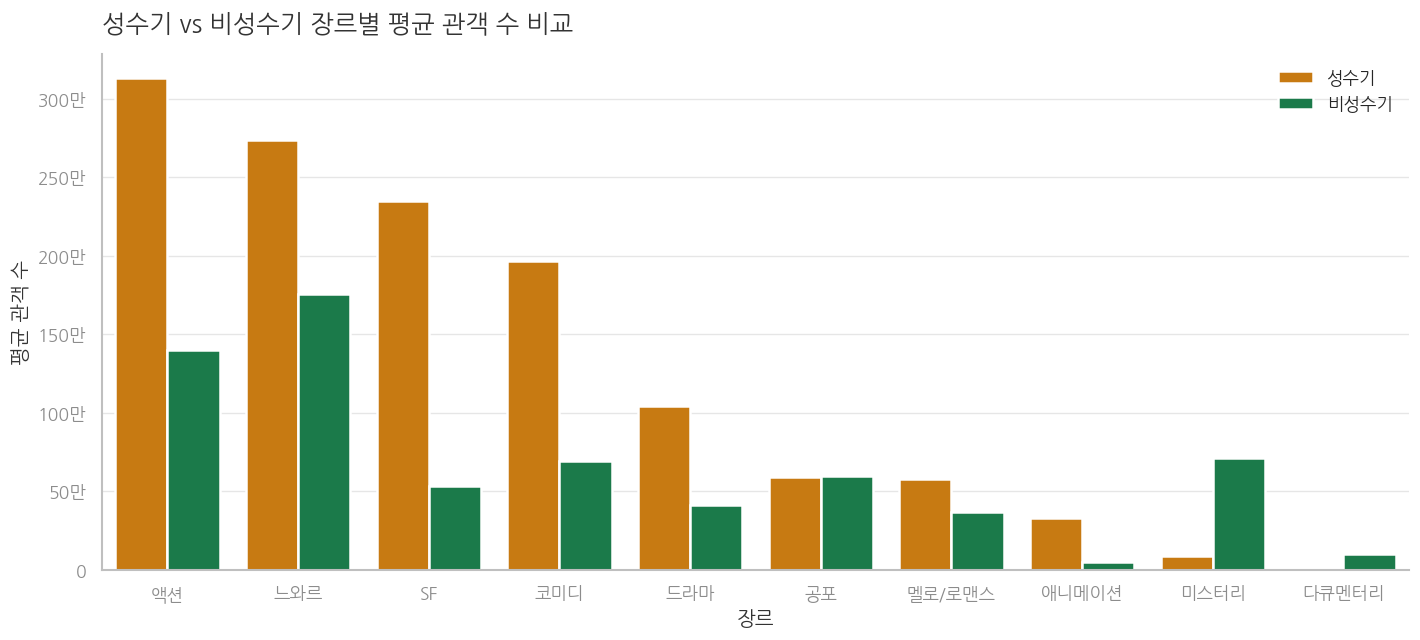

In [ ]:
# 1. 날짜 데이터 변환 및 '개봉 월(month)' 컬럼 생성
df['release_time'] = pd.to_datetime(df['release_time'])
df['month'] = df['release_time'].dt.month

# 2. 성수기 / 비성수기 구분 컬럼 생성 (방학 및 연말 시즌: 1월, 2월, 7월, 8월, 12월)
peak_months = [1, 2, 7, 8, 12]
df['season_type'] = np.where(df['month'].isin(peak_months), '성수기', '비성수기')

# 3. 성수기/비성수기 및 장르별 평균 관객 수 집계
season_genre = df.groupby(['genre', 'season_type'])['box_off_num'].mean().unstack()
season_genre = season_genre.dropna().sort_values('성수기', ascending=False)  # 한쪽 시즌에만 있는 장르 제외
season_genre_df = season_genre.reset_index().melt(id_vars='genre', var_name='season_type', value_name='box_off_num')

# 4. 시각화
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.barplot(data=season_genre_df, x='genre', y='box_off_num', hue='season_type',
            hue_order=['성수기', '비성수기'], palette={'성수기': ACCENT, '비성수기': MAIN},
            order=season_genre.index, saturation=1, edgecolor='white', linewidth=1.5, ax=ax)
ax.legend(title='')
style_ax(ax, '성수기 vs 비성수기 장르별 평균 관객 수 비교', xlabel='장르', ylabel='평균 관객 수', man_y=True)
plt.show()

In [ ]:
# 1) 개봉일 datetime 변환 & 월/계절 추출

df['release_time'] = pd.to_datetime(df['release_time'])
df['release_month'] = df['release_time'].dt.month

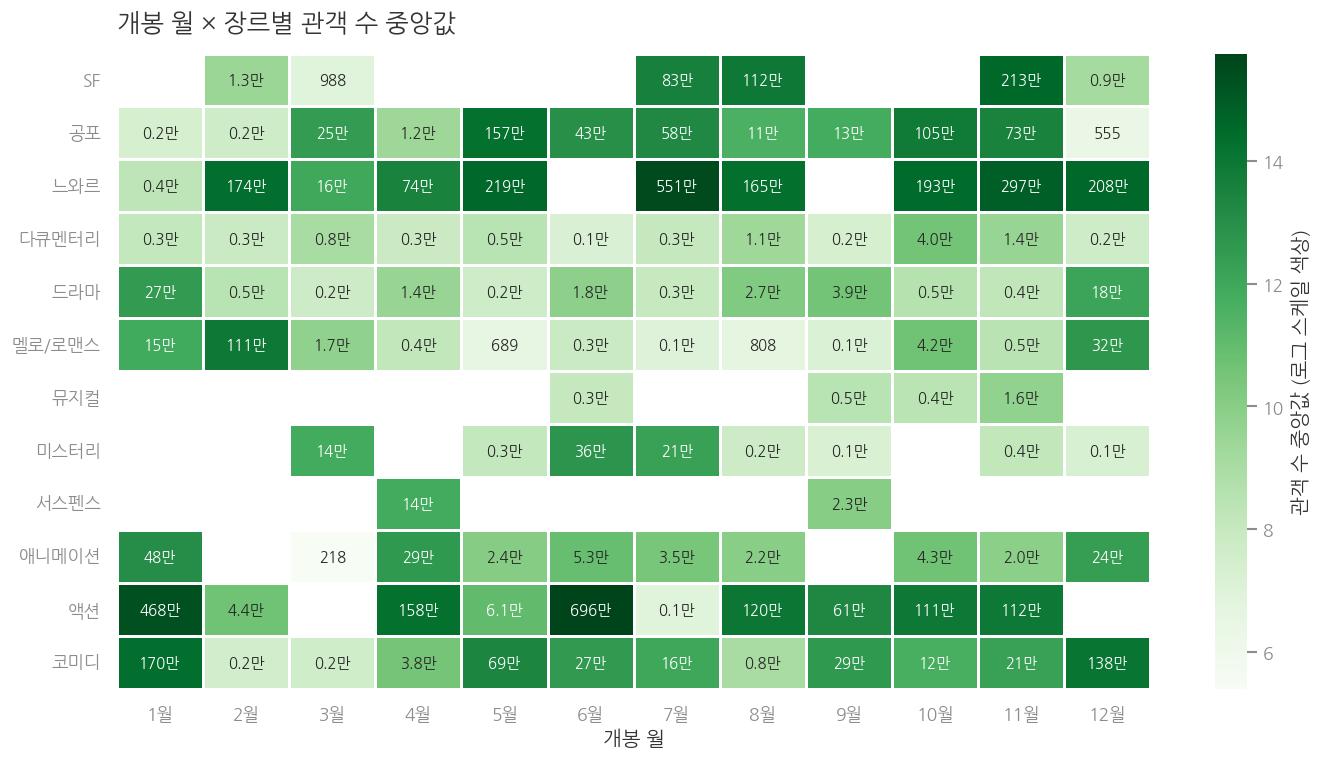

In [ ]:
# 장르 및 개봉월별 관객수 중앙값 피벗 테이블 생성
pivot_df = df.pivot_table(index='genre', columns='release_month', values='box_off_num', aggfunc='median')

def fmt_man(v):
    if np.isnan(v):
        return ''
    m = v / 10000
    return f'{m:.0f}만' if m >= 10 else (f'{m:.1f}만' if m >= 0.1 else f'{int(v)}')

# 히트맵 (색은 로그 스케일, 숫자는 실제 중앙값)
fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(np.log1p(pivot_df), annot=pivot_df.map(fmt_man), fmt='', cmap=SEQ_CMAP,
            linewidths=1.5, linecolor='white', annot_kws={'fontsize': 9},
            cbar_kws={'label': '관객 수 중앙값 (로그 스케일 색상)'}, ax=ax)
ax.set_xticklabels([f'{m}월' for m in pivot_df.columns], rotation=0)
ax.tick_params(axis='y', rotation=0)
style_ax(ax, '개봉 월 × 장르별 관객 수 중앙값', xlabel='개봉 월', ylabel='', ygrid=False)
plt.show()

<결과 해석>

- 최고의 개봉 시즌: 액션과 느와르는 여름 성수기(6, 7월)와 연말연시(12, 1월)에 개봉할 때 흥행 가능성이 가장 높다.

- 타겟 핀포인트: 멜로/로맨스는 발렌타인 데이가 있는 2월, 공포는 여름 직전인 5월이나 가을(10~11월)을 공략하는 것이 유리하다.

- 비수기 회피: 3~4월은 극장가 전체 관객수가 급감하므로 대작 개봉을 피하는 것이 좋다.

## 러닝 타임

### 러닝 타임과 관객수

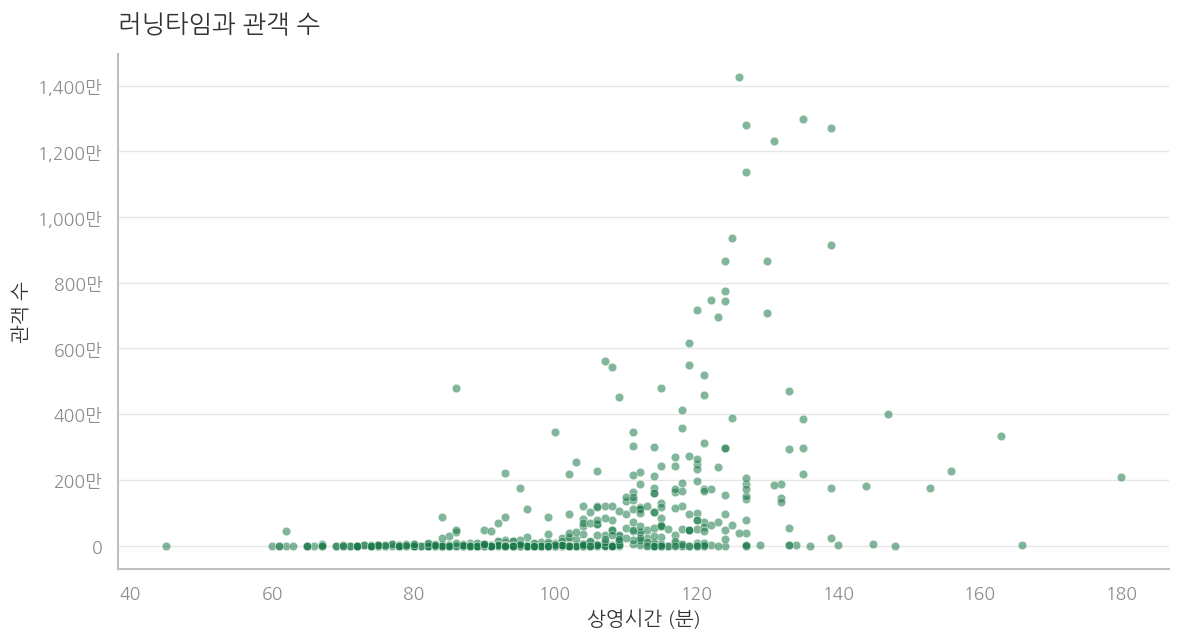

In [ ]:
fig, ax = plt.subplots()
sns.scatterplot(x='time', y='box_off_num', data=df, color=MAIN, **DOT, ax=ax)
style_ax(ax, '러닝타임과 관객 수', xlabel='상영시간 (분)', ylabel='관객 수', man_y=True)
plt.show()

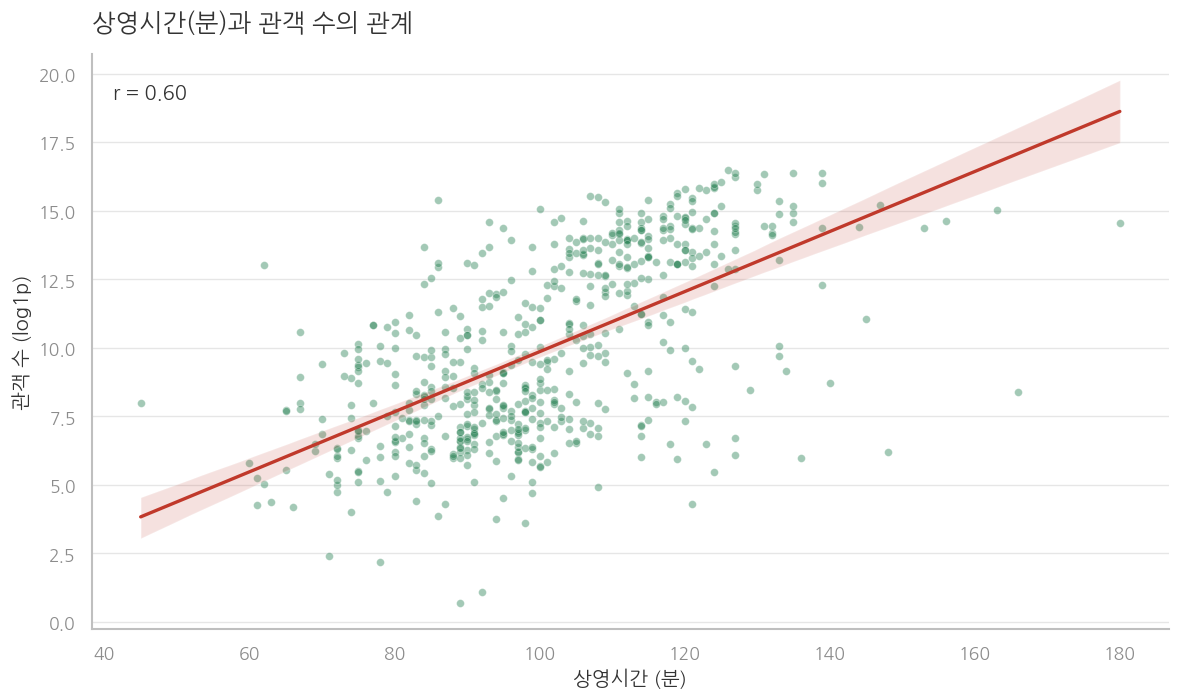

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='time', y=np.log1p(df['box_off_num']), data=df,
            scatter_kws={'s': 22, 'color': MAIN, 'alpha': 0.4, 'edgecolor': 'white', 'linewidths': 0.4},
            line_kws={'color': LINE, 'linewidth': 2}, ax=ax)
r = df['time'].corr(np.log1p(df['box_off_num']))
ax.text(0.02, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=12, color=INK, va='top')
style_ax(ax, '상영시간(분)과 관객 수의 관계', xlabel='상영시간 (분)', ylabel='관객 수 (log1p)')
plt.show()

### 러닝 타임 구간별 평균 관객 수
- 구간을 나누는 기준에 따라 다른 결과 도출

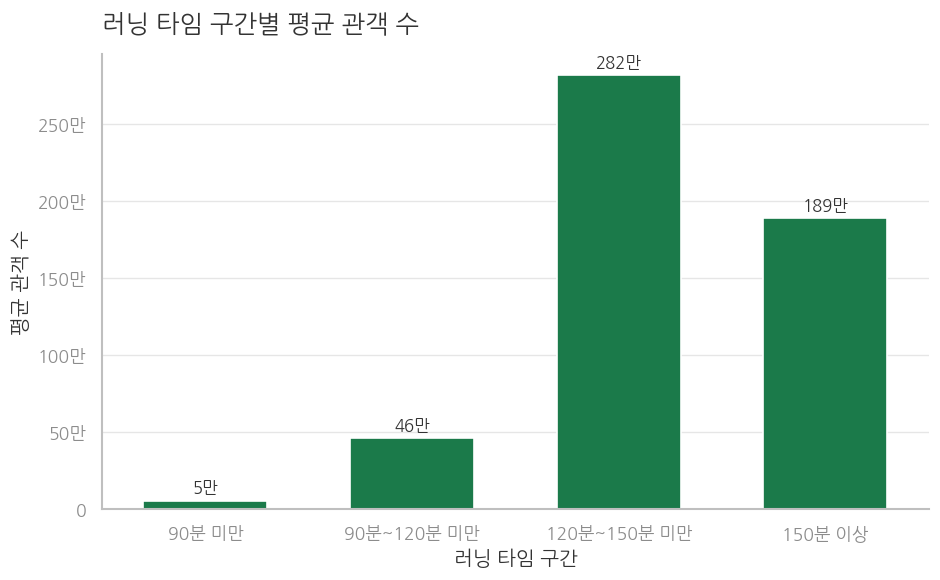

In [ ]:
# 데이터 준비 및 구간 생성
my_df = df.copy()
bins = [0, 90, 120, 150, np.inf]
labels = ['90분 미만', '90분~120분 미만', '120분~150분 미만', '150분 이상']
my_df['time_group'] = pd.cut(my_df['time'], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=my_df, x='time_group', y='box_off_num', errorbar=None,
            color=MAIN, saturation=1, width=0.6, ax=ax)
for c in ax.containers:
    ax.bar_label(c, labels=[f'{v/10000:.0f}만' for v in c.datavalues], fontsize=10, color=INK, padding=3)
style_ax(ax, '러닝 타임 구간별 평균 관객 수', xlabel='러닝 타임 구간', ylabel='평균 관객 수', man_y=True)
plt.show()

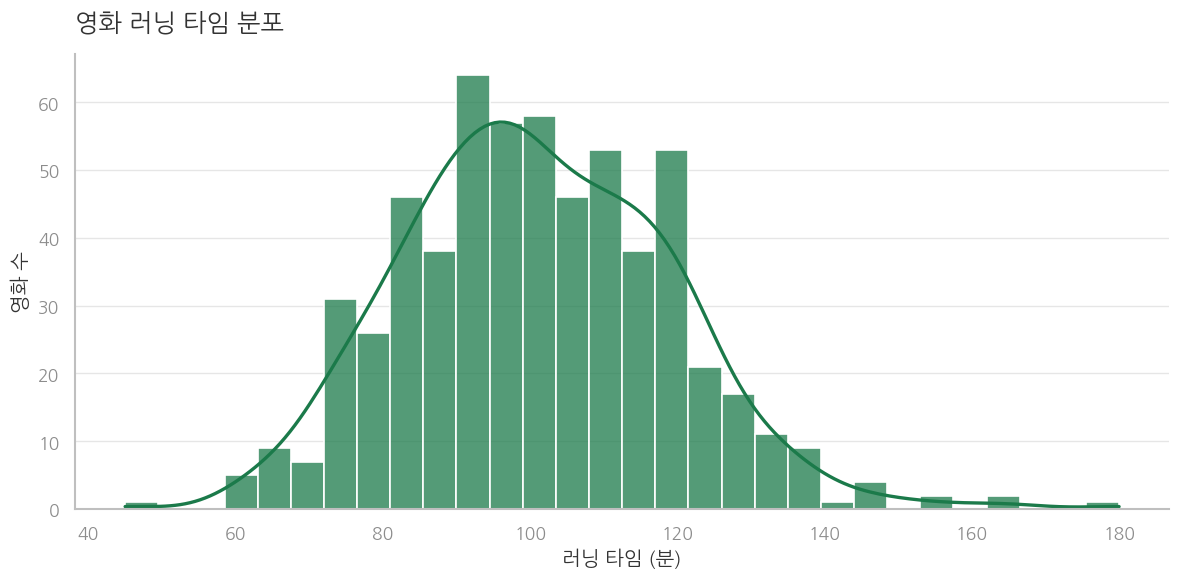

In [ ]:
my_df = df.copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=my_df, x='time', bins=30, kde=True, color=MAIN, alpha=0.75,
             edgecolor='white', linewidth=1, line_kws={'linewidth': 2}, ax=ax)
style_ax(ax, '영화 러닝 타임 분포', xlabel='러닝 타임 (분)', ylabel='영화 수')
plt.show()

### 러닝 타임 사분위수 기준 구간별 평균 관객 수 시각화

In [ ]:
# 실제 경계값 출력하기
my_df['time_group'], bins = pd.qcut(my_df['time'], q=4, retbins=True)

print("사분위수 실제 구간 경계값:")
print(bins)

사분위수 실제 구간 경계값:
[ 45.  89. 100. 114. 180.]


,time_group,영화수,평균관객수,중앙값관객수
0,~Q1 (45~89분),163,54162.0,1611.0
1,~Q2 (89~100분),152,97181.0,2702.0
2,~Q3 (100~114분),147,618234.0,210278.0
3,~Q4 (114~180분),138,2249484.0,1058720.0


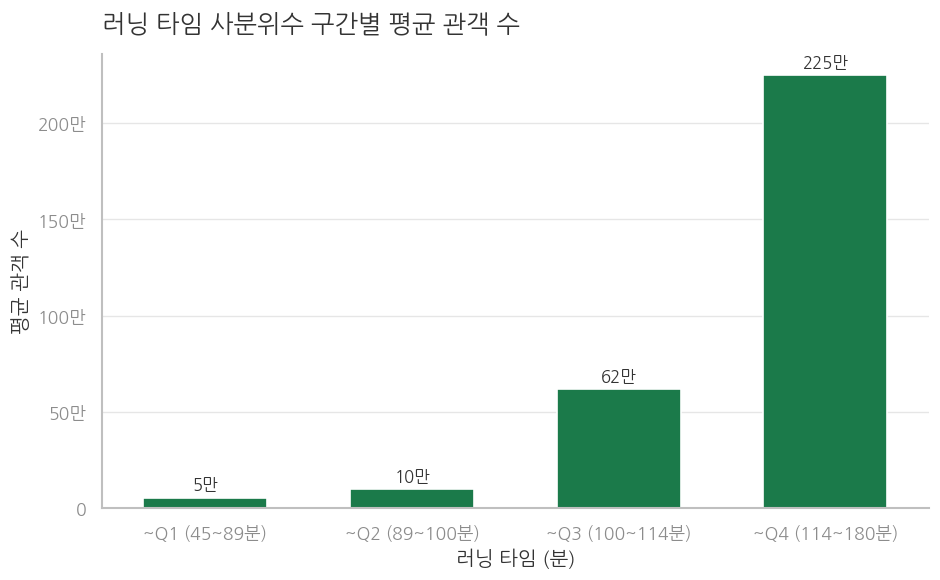

In [ ]:
# 데이터 준비 및 사분위수(Quartile) 기준 구간 생성
my_df = df.copy()

# pd.qcut을 사용하여 러닝 타임을 데이터 개수 기준 4등분 (Q1 ~ Q4)
labels = ['~Q1 (45~89분)', '~Q2 (89~100분)', '~Q3 (100~114분)', '~Q4 (114~180분)']
my_df['time_group'] = pd.qcut(my_df['time'], q=4, labels=labels)

# 구간별 영화 수, 평균 관객 수, 중앙값 관객 수 집계 (표 만들기)
time_analysis = my_df.groupby('time_group', observed=False)['box_off_num'].agg(
    영화수='count',
    평균관객수='mean',
    중앙값관객수='median'
).reset_index()
time_analysis['평균관객수'] = time_analysis['평균관객수'].round(0)
time_analysis['중앙값관객수'] = time_analysis['중앙값관객수'].round(0)
display(time_analysis)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=my_df, x='time_group', y='box_off_num', errorbar=None,
            color=MAIN, saturation=1, width=0.6, ax=ax)
for c in ax.containers:
    ax.bar_label(c, labels=[f'{v/10000:.0f}만' for v in c.datavalues], fontsize=10, color=INK, padding=3)
style_ax(ax, '러닝 타임 사분위수 구간별 평균 관객 수', xlabel='러닝 타임 (분)', ylabel='평균 관객 수', man_y=True)
plt.show()

비슷한 상영시간에서도 스태프 수와 관객수의 관계가 보일까?

In [ ]:
# 탐색을 위해 상영시간을 세 구간으로 구분
def time_group(time):
    if time < 90:
        return '90분 미만'
    elif time < 120:
        return '90~119분'
    else:
        return '120분 이상'

df['time_group'] = df['time'].apply(time_group)

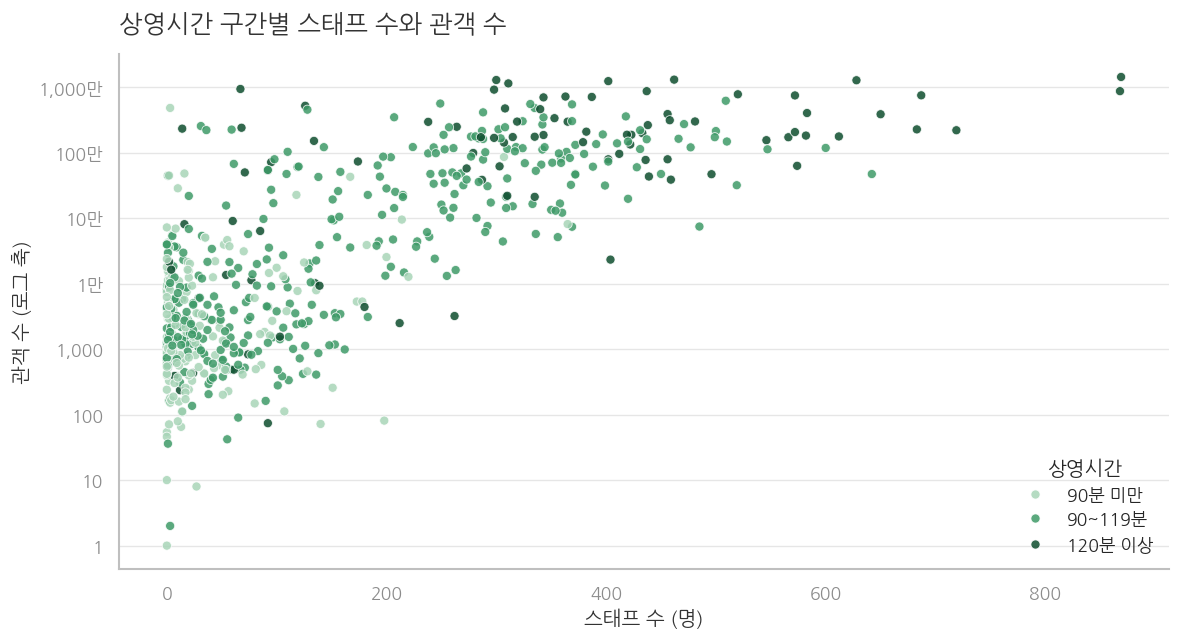

In [ ]:
order = ['90분 미만', '90~119분', '120분 이상']

fig, ax = plt.subplots()
sns.scatterplot(x='num_staff', y='box_off_num', hue='time_group', hue_order=order,
                palette=dict(zip(order, SEQ3)), data=df,
                s=30, alpha=0.85, edgecolor='white', linewidth=0.5, ax=ax)
ax.set_yscale('log')
ax.legend(title='상영시간', loc='lower right')
style_ax(ax, '상영시간 구간별 스태프 수와 관객 수', xlabel='스태프 수 (명)', ylabel='관객 수 (로그 축)', man_y=True)
plt.show()